In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        has_root_files = (candidate / "train.csv").exists() and (candidate / "test.csv").exists()
        has_data_files = (candidate / "data" / "train.csv").exists() and (candidate / "data" / "test.csv").exists()
        if has_root_files or has_data_files:
            return candidate
    raise FileNotFoundError("Could not locate project root from the current notebook working directory.")


PROJECT_ROOT = find_project_root()


def resolve_data_path(filename: str) -> Path:
    candidates = [
        PROJECT_ROOT / filename,
        PROJECT_ROOT / "data" / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f"Could not find {filename} in project root or data/")


train_path = resolve_data_path("train.csv")
test_path = resolve_data_path("test.csv")
submission_path = resolve_data_path("sample_submission.csv")

train = pd.read_csv(train_path, parse_dates=["date"])
test = pd.read_csv(test_path, parse_dates=["date"])
sample_submission = pd.read_csv(submission_path)

print("Current working directory:", Path.cwd())
print("Project root:", PROJECT_ROOT)
print("Resolved paths:")
print("train ->", train_path)
print("test ->", test_path)
print("sample_submission ->", submission_path)

display(train.head())
display(test.head())
display(sample_submission.head())
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

Current working directory: /Users/sauravkrishna/Documents/projects/NQFO-Impilied-volatility-surface/notebooks
Project root: /Users/sauravkrishna/Documents/projects/NQFO-Impilied-volatility-surface
Resolved paths:
train -> /Users/sauravkrishna/Documents/projects/NQFO-Impilied-volatility-surface/train.csv
test -> /Users/sauravkrishna/Documents/projects/NQFO-Impilied-volatility-surface/test.csv
sample_submission -> /Users/sauravkrishna/Documents/projects/NQFO-Impilied-volatility-surface/sample_submission.csv


,row_id,date,spot,strike,moneyness,option_type,maturity_label,maturity_days,tau,iv_observed
0,0,2025-01-02,"22,140.3800",17700,0.8000,call,1M,30,0.1191,25.0100
1,1,2025-01-02,"22,140.3800",17700,0.8000,put,1M,30,0.1191,NaN
2,2,2025-01-02,"22,140.3800",18800,0.8500,call,1M,30,0.1191,NaN
3,3,2025-01-02,"22,140.3800",18800,0.8500,put,1M,30,0.1191,NaN
4,4,2025-01-02,"22,140.3800",19350,0.8750,call,1M,30,0.1191,22.7692


,row_id,date,spot,strike,moneyness,option_type,maturity_label,maturity_days,tau,iv_observed
0,11640,2025-05-19,"20,254.5700",16200,0.8000,call,1M,30,0.1191,20.6631
1,11641,2025-05-19,"20,254.5700",16200,0.8000,put,1M,30,0.1191,25.0712
2,11642,2025-05-19,"20,254.5700",17200,0.8500,call,1M,30,0.1191,20.3932
3,11643,2025-05-19,"20,254.5700",17200,0.8500,put,1M,30,0.1191,NaN
4,11644,2025-05-19,"20,254.5700",17700,0.8750,call,1M,30,0.1191,20.0060


,row_id,iv_predicted
0,11643,18.0000
1,11645,18.0000
2,11648,18.0000
3,11650,18.0000
4,11651,18.0000


Train shape: (11640, 10)
Test shape: (3960, 10)
Sample submission shape: (1699, 2)


In [3]:
def dataset_summary(df: pd.DataFrame, name: str) -> pd.Series:
    return pd.Series(
        {
            "rows": len(df),
            "columns": df.shape[1],
            "date_min": df["date"].min(),
            "date_max": df["date"].max(),
            "n_dates": df["date"].nunique(),
            "missing_iv": int(df["iv_observed"].isna().sum()),
            "visible_iv": int(df["iv_observed"].notna().sum()),
            "visible_iv_ratio": df["iv_observed"].notna().mean(),
            "n_moneyness": df["moneyness"].nunique(),
            "n_maturity_labels": df["maturity_label"].nunique(),
            "n_option_types": df["option_type"].nunique(),
        },
        name=name,
    )

summary = pd.DataFrame(
    [
        dataset_summary(train, "train"),
        dataset_summary(test, "test"),
    ]
)

display(summary)
print("Train ends before test begins:", train["date"].max() < test["date"].min())


,rows,columns,date_min,date_max,n_dates,missing_iv,visible_iv,visible_iv_ratio,n_moneyness,n_maturity_labels,n_option_types
train,11640,10,2025-01-02,2025-05-16,97,5148,6492,0.5577,15,4,2
test,3960,10,2025-05-19,2025-07-02,33,1699,2261,0.5710,15,4,2


Train ends before test begins: True


In [4]:
def per_date_structure(df: pd.DataFrame, name: str):
    by_date = (
        df.groupby("date")
        .agg(
            rows=("row_id", "size"),
            visible_iv=("iv_observed", lambda s: s.notna().sum()),
            missing_iv=("iv_observed", lambda s: s.isna().sum()),
            visible_ratio=("iv_observed", lambda s: s.notna().mean()),
            n_moneyness=("moneyness", "nunique"),
            n_maturity_labels=("maturity_label", "nunique"),
            n_option_types=("option_type", "nunique"),
        )
        .sort_index()
    )
    print(f"{name} per-date structure")
    display(by_date.describe().T)
    display(by_date.head())
    return by_date

train_by_date = per_date_structure(train, "train")
test_by_date = per_date_structure(test, "test")


train per-date structure


,count,mean,std,min,25%,50%,75%,max
rows,97.0000,120.0000,0.0000,120.0000,120.0000,120.0000,120.0000,120.0000
visible_iv,97.0000,66.9278,4.9228,56.0000,63.0000,67.0000,71.0000,79.0000
missing_iv,97.0000,53.0722,4.9228,41.0000,49.0000,53.0000,57.0000,64.0000
visible_ratio,97.0000,0.5577,0.0410,0.4667,0.5250,0.5583,0.5917,0.6583
n_moneyness,97.0000,15.0000,0.0000,15.0000,15.0000,15.0000,15.0000,15.0000
n_maturity_labels,97.0000,4.0000,0.0000,4.0000,4.0000,4.0000,4.0000,4.0000
n_option_types,97.0000,2.0000,0.0000,2.0000,2.0000,2.0000,2.0000,2.0000


,rows,visible_iv,missing_iv,visible_ratio,n_moneyness,n_maturity_labels,n_option_types
date,,,,,,,
2025-01-02,120,65,55,0.5417,15,4,2
2025-01-03,120,64,56,0.5333,15,4,2
2025-01-06,120,73,47,0.6083,15,4,2
2025-01-07,120,71,49,0.5917,15,4,2
2025-01-08,120,72,48,0.6000,15,4,2


test per-date structure


,count,mean,std,min,25%,50%,75%,max
rows,33.0000,120.0000,0.0000,120.0000,120.0000,120.0000,120.0000,120.0000
visible_iv,33.0000,68.5152,5.3568,59.0000,65.0000,68.0000,72.0000,80.0000
missing_iv,33.0000,51.4848,5.3568,40.0000,48.0000,52.0000,55.0000,61.0000
visible_ratio,33.0000,0.5710,0.0446,0.4917,0.5417,0.5667,0.6000,0.6667
n_moneyness,33.0000,15.0000,0.0000,15.0000,15.0000,15.0000,15.0000,15.0000
n_maturity_labels,33.0000,4.0000,0.0000,4.0000,4.0000,4.0000,4.0000,4.0000
n_option_types,33.0000,2.0000,0.0000,2.0000,2.0000,2.0000,2.0000,2.0000


,rows,visible_iv,missing_iv,visible_ratio,n_moneyness,n_maturity_labels,n_option_types
date,,,,,,,
2025-05-19,120,63,57,0.5250,15,4,2
2025-05-20,120,69,51,0.5750,15,4,2
2025-05-21,120,63,57,0.5250,15,4,2
2025-05-22,120,68,52,0.5667,15,4,2
2025-05-23,120,68,52,0.5667,15,4,2


In [5]:
train_lattice = {
    "moneyness_levels": sorted(train["moneyness"].unique().tolist()),
    "maturity_labels": sorted(train["maturity_label"].unique().tolist()),
    "option_types": sorted(train["option_type"].unique().tolist()),
}
test_lattice = {
    "moneyness_levels": sorted(test["moneyness"].unique().tolist()),
    "maturity_labels": sorted(test["maturity_label"].unique().tolist()),
    "option_types": sorted(test["option_type"].unique().tolist()),
}

expected_rows_per_date = (
    len(train_lattice["moneyness_levels"])
    * len(train_lattice["maturity_labels"])
    * len(train_lattice["option_types"])
)

print("Expected rows per date from lattice:", expected_rows_per_date)
print("Unique train rows/date:", sorted(train_by_date["rows"].unique().tolist()))
print("Unique test rows/date:", sorted(test_by_date["rows"].unique().tolist()))
print("Train/test share same moneyness grid:", train_lattice["moneyness_levels"] == test_lattice["moneyness_levels"])
print("Train/test share same maturity labels:", train_lattice["maturity_labels"] == test_lattice["maturity_labels"])
print("Train/test share same option types:", train_lattice["option_types"] == test_lattice["option_types"])


Expected rows per date from lattice: 120
Unique train rows/date: [120]
Unique test rows/date: [120]
Train/test share same moneyness grid: True
Train/test share same maturity labels: True
Train/test share same option types: True


In [6]:
def missingness_breakdown(df: pd.DataFrame, name: str):
    print(f"\n{name} missingness by option_type")
    by_option = (
        df.groupby("option_type")["iv_observed"]
        .agg(
            total_rows="size",
            visible_iv=lambda s: s.notna().sum(),
            missing_iv=lambda s: s.isna().sum(),
            visible_ratio=lambda s: s.notna().mean(),
        )
    )
    display(by_option)

    print(f"\n{name} missingness by maturity_label")
    by_maturity = (
        df.groupby("maturity_label")["iv_observed"]
        .agg(
            total_rows="size",
            visible_iv=lambda s: s.notna().sum(),
            missing_iv=lambda s: s.isna().sum(),
            visible_ratio=lambda s: s.notna().mean(),
        )
        .sort_index()
    )
    display(by_maturity)

missingness_breakdown(train, "train")
missingness_breakdown(test, "test")



train missingness by option_type


,total_rows,visible_iv,missing_iv,visible_ratio
option_type,,,,
call,5820,3209,2611,0.5514
put,5820,3283,2537,0.5641



train missingness by maturity_label


,total_rows,visible_iv,missing_iv,visible_ratio
maturity_label,,,,
1M,2910,1435,1475,0.4931
2M,2910,1696,1214,0.5828
3M,2910,1674,1236,0.5753
6M,2910,1687,1223,0.5797



test missingness by option_type


,total_rows,visible_iv,missing_iv,visible_ratio
option_type,,,,
call,1980,1135,845,0.5732
put,1980,1126,854,0.5687



test missingness by maturity_label


,total_rows,visible_iv,missing_iv,visible_ratio
maturity_label,,,,
1M,990,504,486,0.5091
2M,990,574,416,0.5798
3M,990,591,399,0.5970
6M,990,592,398,0.5980


In [7]:
train_anchor_stats = (
    train.groupby("date")["iv_observed"]
    .agg(
        visible_iv=lambda s: s.notna().sum(),
        missing_iv=lambda s: s.isna().sum(),
        visible_ratio=lambda s: s.notna().mean(),
    )
    .sort_index()
)

test_anchor_stats = (
    test.groupby("date")["iv_observed"]
    .agg(
        visible_iv=lambda s: s.notna().sum(),
        missing_iv=lambda s: s.isna().sum(),
        visible_ratio=lambda s: s.notna().mean(),
    )
    .sort_index()
)

print("Train anchor coverage summary")
display(train_anchor_stats.describe().T)

print("Test anchor coverage summary")
display(test_anchor_stats.describe().T)

print("Lowest-anchor test dates")
display(test_anchor_stats.sort_values("visible_ratio").head(10))

print("Highest-anchor test dates")
display(test_anchor_stats.sort_values("visible_ratio", ascending=False).head(10))


Train anchor coverage summary


,count,mean,std,min,25%,50%,75%,max
visible_iv,97.0000,66.9278,4.9228,56.0000,63.0000,67.0000,71.0000,79.0000
missing_iv,97.0000,53.0722,4.9228,41.0000,49.0000,53.0000,57.0000,64.0000
visible_ratio,97.0000,0.5577,0.0410,0.4667,0.5250,0.5583,0.5917,0.6583


Test anchor coverage summary


,count,mean,std,min,25%,50%,75%,max
visible_iv,33.0000,68.5152,5.3568,59.0000,65.0000,68.0000,72.0000,80.0000
missing_iv,33.0000,51.4848,5.3568,40.0000,48.0000,52.0000,55.0000,61.0000
visible_ratio,33.0000,0.5710,0.0446,0.4917,0.5417,0.5667,0.6000,0.6667


Lowest-anchor test dates


,visible_iv,missing_iv,visible_ratio
date,,,
2025-05-28,59,61,0.4917
2025-05-29,60,60,0.5000
2025-06-30,61,59,0.5083
2025-05-19,63,57,0.5250
2025-05-21,63,57,0.5250
2025-05-30,63,57,0.5250
2025-06-18,64,56,0.5333
2025-06-12,64,56,0.5333
2025-06-19,65,55,0.5417


Highest-anchor test dates


,visible_iv,missing_iv,visible_ratio
date,,,
2025-06-11,80,40,0.6667
2025-06-25,78,42,0.6500
2025-06-02,77,43,0.6417
2025-06-04,76,44,0.6333
2025-05-27,75,45,0.6250
2025-07-01,74,46,0.6167
2025-06-23,73,47,0.6083
2025-06-17,73,47,0.6083
2025-05-26,72,48,0.6000


In [8]:
train_grid_missingness = (
    train.assign(is_visible=train["iv_observed"].notna())
    .groupby(["maturity_label", "option_type"])["is_visible"]
    .mean()
    .rename("visible_ratio")
    .reset_index()
    .pivot(index="maturity_label", columns="option_type", values="visible_ratio")
    .sort_index()
)

test_grid_missingness = (
    test.assign(is_visible=test["iv_observed"].notna())
    .groupby(["maturity_label", "option_type"])["is_visible"]
    .mean()
    .rename("visible_ratio")
    .reset_index()
    .pivot(index="maturity_label", columns="option_type", values="visible_ratio")
    .sort_index()
)

print("Train visible ratio by maturity x option_type")
display(train_grid_missingness)

print("Test visible ratio by maturity x option_type")
display(test_grid_missingness)


Train visible ratio by maturity x option_type


option_type,call,put
maturity_label,,
1M,0.4880,0.4983
2M,0.5814,0.5842
3M,0.5684,0.5821
6M,0.5677,0.5918


Test visible ratio by maturity x option_type


option_type,call,put
maturity_label,,
1M,0.5091,0.5091
2M,0.5697,0.5899
3M,0.6081,0.5859
6M,0.6061,0.5899


In [9]:
common_test_rows = test.copy()
common_test_rows["is_missing_target"] = common_test_rows["iv_observed"].isna()

target_pattern = (
    common_test_rows.groupby(["maturity_label", "option_type"])["is_missing_target"]
    .agg(
        total_rows="size",
        target_rows="sum",
        target_ratio="mean",
    )
    .reset_index()
    .sort_values(["maturity_label", "option_type"])
)

print("Test prediction target pattern by maturity x option_type")
display(target_pattern)


Test prediction target pattern by maturity x option_type


,maturity_label,option_type,total_rows,target_rows,target_ratio
0,1M,call,495,243,0.4909
1,1M,put,495,243,0.4909
2,2M,call,495,213,0.4303
3,2M,put,495,203,0.4101
4,3M,call,495,194,0.3919
5,3M,put,495,205,0.4141
6,6M,call,495,195,0.3939
7,6M,put,495,203,0.4101


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

moneyness_order = sorted(train["moneyness"].unique().tolist())
maturity_order = sorted(train["maturity_label"].unique().tolist(), key=lambda x: int(x[:-1]))
option_order = ["call", "put"]


In [11]:
def missingness_by_moneyness(df: pd.DataFrame, name: str):
    out = (
        df.assign(is_visible=df["iv_observed"].notna())
        .groupby("moneyness")
        .agg(
            total_rows=("row_id", "size"),
            visible_iv=("is_visible", "sum"),
            missing_iv=("is_visible", lambda s: (~s).sum()),
            visible_ratio=("is_visible", "mean"),
        )
        .reindex(moneyness_order)
    )
    print(f"{name} missingness by moneyness")
    display(out)
    return out

train_by_moneyness = missingness_by_moneyness(train, "train")
test_by_moneyness = missingness_by_moneyness(test, "test")


train missingness by moneyness


,total_rows,visible_iv,missing_iv,visible_ratio
moneyness,,,,
0.8000,776,400,376,0.5155
0.8500,776,387,389,0.4987
0.8750,776,370,406,0.4768
0.9000,776,487,289,0.6276
0.9250,776,450,326,0.5799
0.9500,776,469,307,0.6044
0.9750,776,470,306,0.6057
1.0000,776,484,292,0.6237
1.0250,776,466,310,0.6005


test missingness by moneyness


,total_rows,visible_iv,missing_iv,visible_ratio
moneyness,,,,
0.8000,264,139,125,0.5265
0.8500,264,141,123,0.5341
0.8750,264,140,124,0.5303
0.9000,264,168,96,0.6364
0.9250,264,155,109,0.5871
0.9500,264,168,96,0.6364
0.9750,264,160,104,0.6061
1.0000,264,171,93,0.6477
1.0250,264,160,104,0.6061


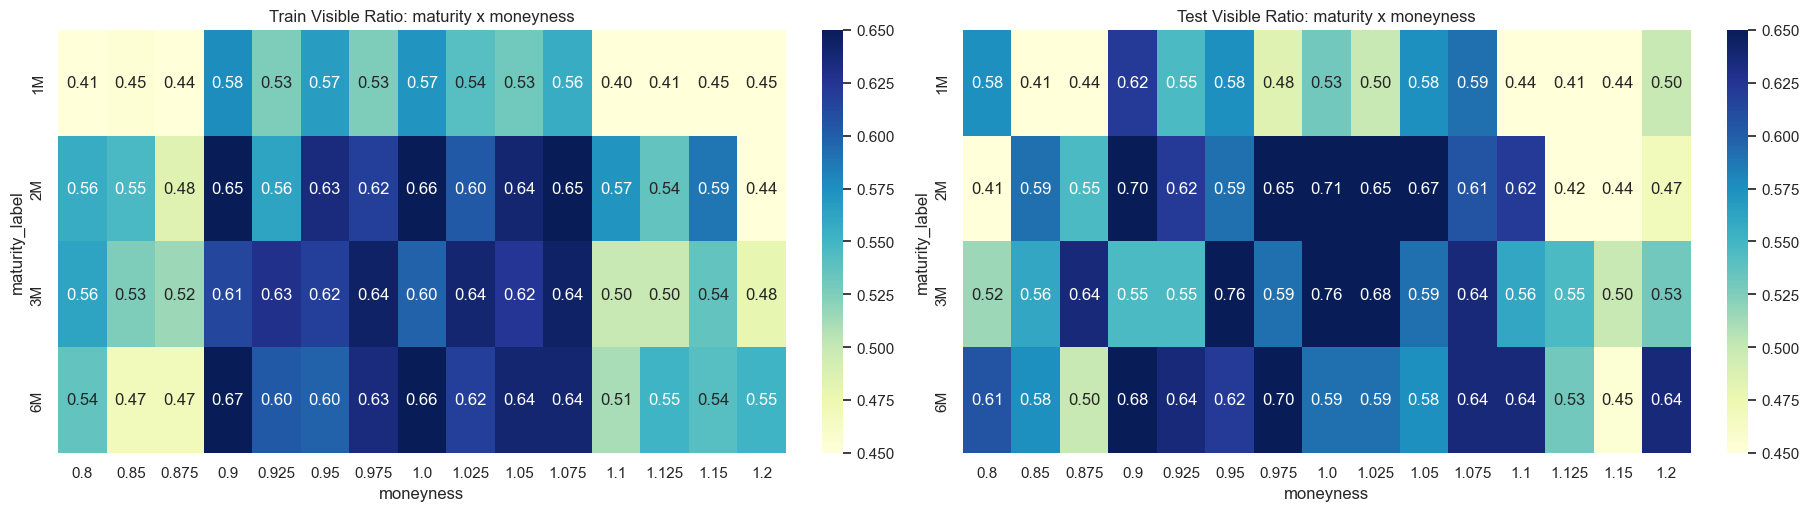

In [12]:
def visible_ratio_grid(df: pd.DataFrame):
    return (
        df.assign(is_visible=df["iv_observed"].notna())
        .pivot_table(
            index="maturity_label",
            columns="moneyness",
            values="is_visible",
            aggfunc="mean",
        )
        .reindex(index=maturity_order, columns=moneyness_order)
    )

train_visible_grid = visible_ratio_grid(train)
test_visible_grid = visible_ratio_grid(test)

fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)

sns.heatmap(train_visible_grid, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0.45, vmax=0.65, ax=axes[0])
axes[0].set_title("Train Visible Ratio: maturity x moneyness")
axes[0].set_xlabel("moneyness")
axes[0].set_ylabel("maturity_label")

sns.heatmap(test_visible_grid, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0.45, vmax=0.65, ax=axes[1])
axes[1].set_title("Test Visible Ratio: maturity x moneyness")
axes[1].set_xlabel("moneyness")
axes[1].set_ylabel("maturity_label")

plt.show()


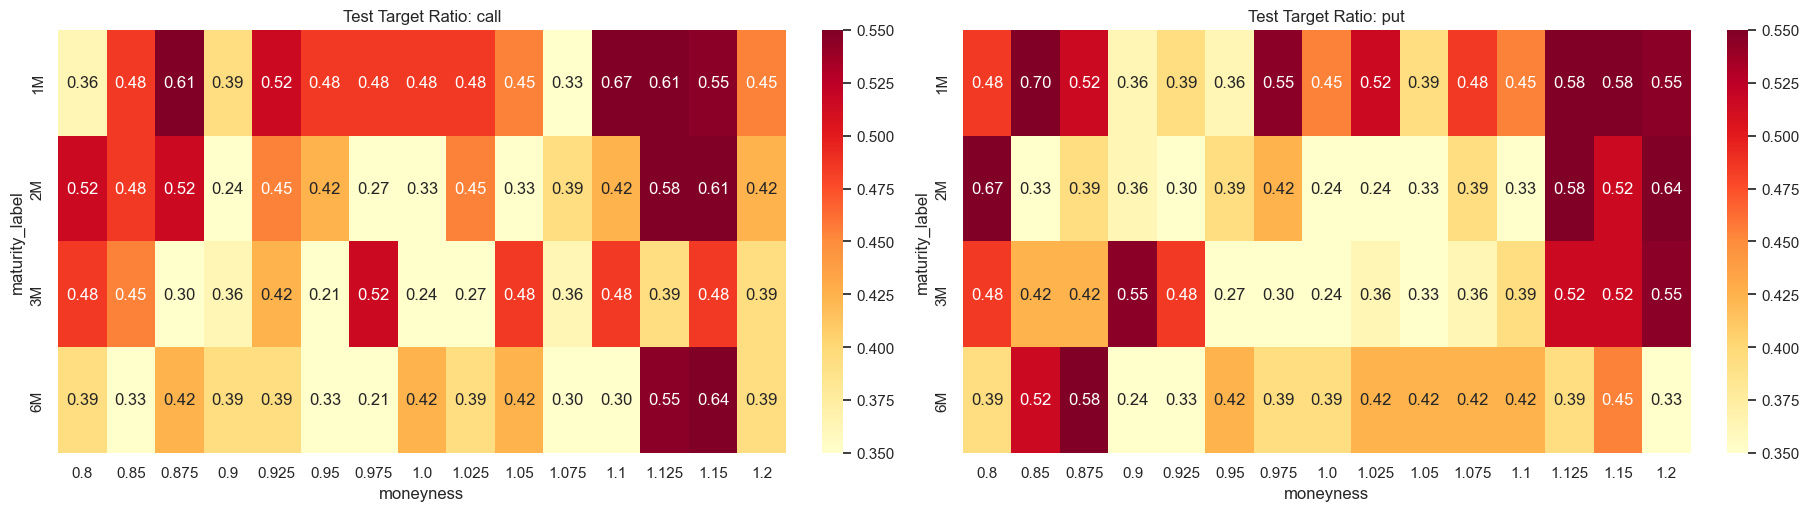

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)

for ax, opt in zip(axes, option_order):
    target_grid = (
        test.assign(is_target=test["iv_observed"].isna())
        .query("option_type == @opt")
        .pivot_table(
            index="maturity_label",
            columns="moneyness",
            values="is_target",
            aggfunc="mean",
        )
        .reindex(index=maturity_order, columns=moneyness_order)
    )
    sns.heatmap(target_grid, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0.35, vmax=0.55, ax=ax)
    ax.set_title(f"Test Target Ratio: {opt}")
    ax.set_xlabel("moneyness")
    ax.set_ylabel("maturity_label")

plt.show()


In [14]:
observed_train = train.loc[train["iv_observed"].notna()].copy()
observed_test = test.loc[test["iv_observed"].notna()].copy()

for df in (observed_train, observed_test):
    df["log_moneyness"] = np.log(df["moneyness"])
    df["total_variance"] = (df["iv_observed"] / 100.0) ** 2 * df["tau"]

def iv_summary(df: pd.DataFrame, name: str):
    print(f"{name} observed IV summary")
    display(
        df.groupby(["maturity_label", "option_type"])["iv_observed"]
        .agg(count="size", mean="mean", std="std", min="min", median="median", max="max")
        .round(4)
    )

iv_summary(observed_train, "Train")
iv_summary(observed_test, "Test visible anchors")


Train observed IV summary


count    mean    std     min  median     max
maturity_label option_type                                              
1M             call           710 21.2424 4.5953 13.7101 20.2540 34.3366
               put            725 21.4544 5.3799 11.3107 20.4697 37.0876
2M             call           846 20.1942 4.3598 13.2963 19.2670 32.1563
               put            850 20.4087 4.7886 11.6443 19.5397 33.5510
3M             call           827 19.6279 4.1152 13.1074 18.8553 30.2548
               put            847 19.5637 4.4389 11.7496 18.5905 32.1605
6M             call           826 18.6993 3.8717 13.2957 18.0924 28.5032
               put            861 18.4709 3.8293 12.5256 17.9194 28.7829

Test visible anchors observed IV summary


count    mean    std     min  median     max
maturity_label option_type                                              
1M             call           252 22.2367 4.7340 13.6469 20.9328 34.5115
               put            252 22.0846 5.0005 12.8308 21.4176 36.0754
2M             call           282 21.0513 4.1347 13.6597 20.0703 32.3246
               put            292 20.8818 4.5691 12.0706 20.0115 34.2539
3M             call           301 20.2890 3.8421 13.2146 19.3380 30.2992
               put            290 20.2852 4.1732 12.7904 19.5042 31.3187
6M             call           300 19.6023 3.7232 13.0179 18.6255 27.9566
               put            292 19.5388 3.8363 12.7591 18.4628 29.4210

Representative dates
Train: 2025-04-14 | visible IV rows: 79
Test : 2025-06-11 | visible IV rows: 80


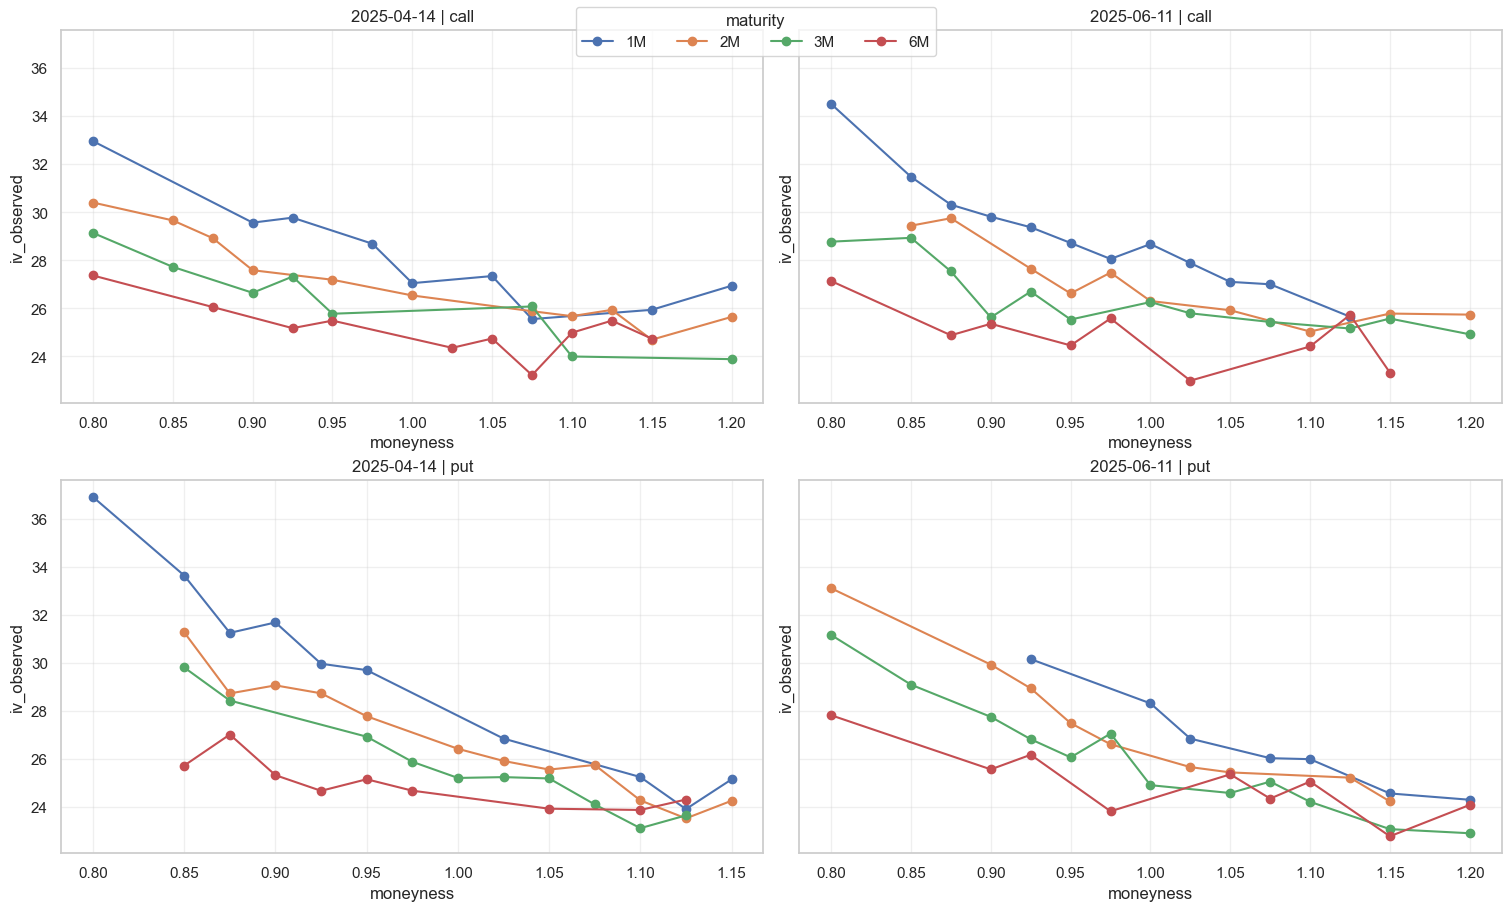

In [15]:
best_train_date = train_by_date["visible_iv"].idxmax()
best_test_date = test_anchor_stats["visible_iv"].idxmax()

plot_dates = [best_train_date, best_test_date]
plot_sources = {
    best_train_date: observed_train,
    best_test_date: observed_test,
}

print("Representative dates")
print("Train:", best_train_date.date(), "| visible IV rows:", int(train_by_date.loc[best_train_date, "visible_iv"]))
print("Test :", best_test_date.date(), "| visible IV rows:", int(test_anchor_stats.loc[best_test_date, "visible_iv"]))

fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharey=True, constrained_layout=True)

for col, d in enumerate(plot_dates):
    day_df = plot_sources[d]
    day_df = day_df[day_df["date"] == d]
    for row, opt in enumerate(option_order):
        ax = axes[row, col]
        subset = day_df[day_df["option_type"] == opt]
        for mat in maturity_order:
            s = subset[subset["maturity_label"] == mat].sort_values("moneyness")
            ax.plot(s["moneyness"], s["iv_observed"], marker="o", label=mat)
        ax.set_title(f"{d.date()} | {opt}")
        ax.set_xlabel("moneyness")
        ax.set_ylabel("iv_observed")
        ax.grid(alpha=0.3)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="maturity", loc="upper center", ncol=len(maturity_order))
plt.show()


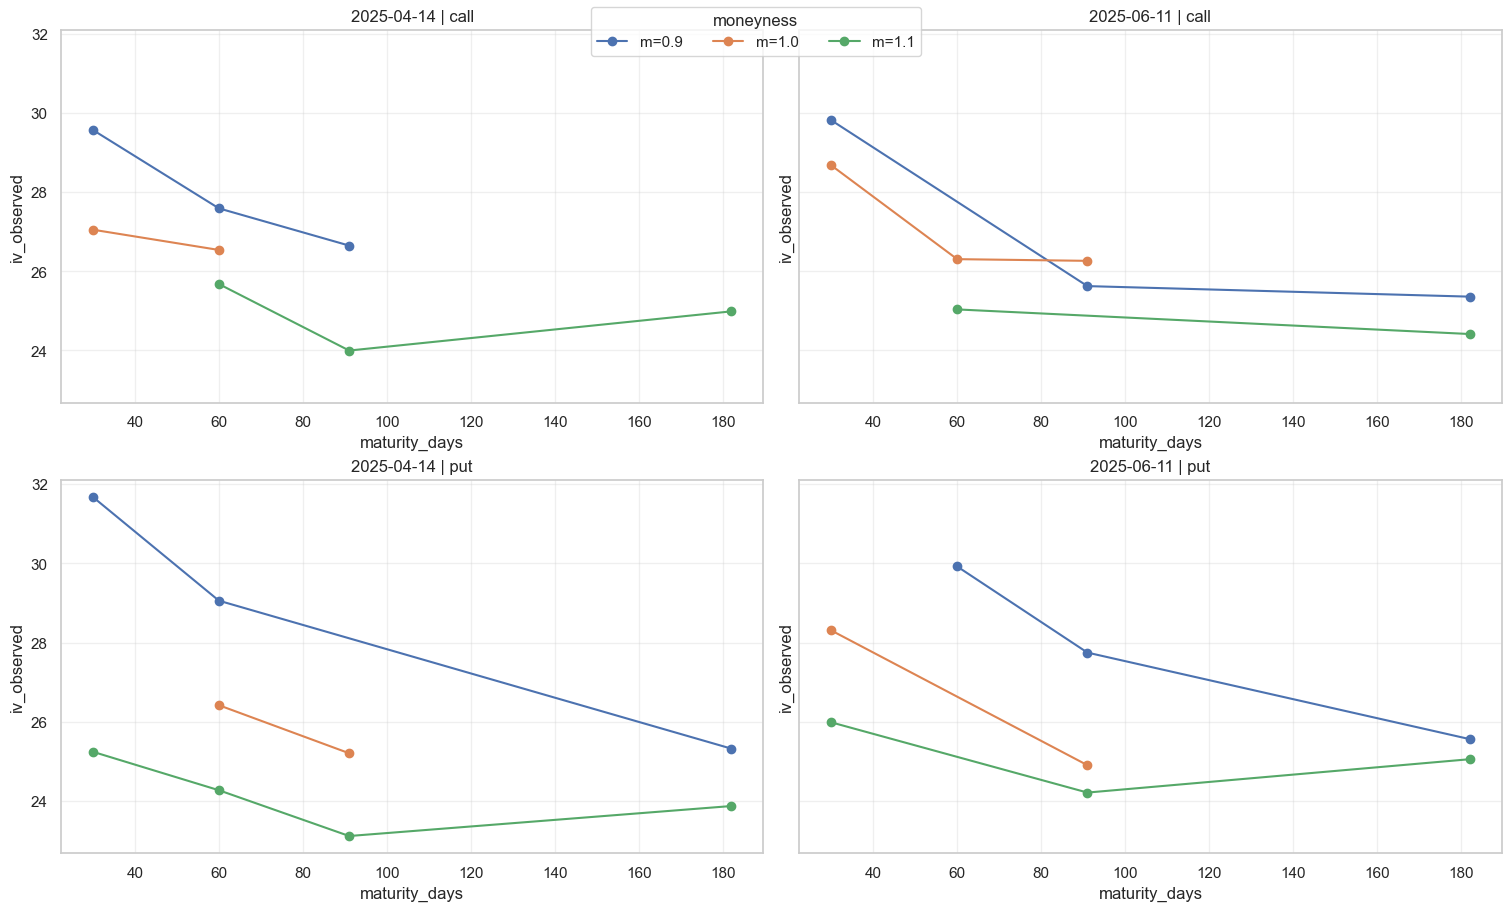

In [16]:
selected_moneyness = [0.9, 1.0, 1.1]

fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharey=True, constrained_layout=True)

for col, d in enumerate(plot_dates):
    day_df = plot_sources[d]
    day_df = day_df[day_df["date"] == d]
    for row, opt in enumerate(option_order):
        ax = axes[row, col]
        subset = day_df[day_df["option_type"] == opt]
        for m in selected_moneyness:
            s = subset[subset["moneyness"] == m].sort_values("maturity_days")
            ax.plot(s["maturity_days"], s["iv_observed"], marker="o", label=f"m={m}")
        ax.set_title(f"{d.date()} | {opt}")
        ax.set_xlabel("maturity_days")
        ax.set_ylabel("iv_observed")
        ax.grid(alpha=0.3)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="moneyness", loc="upper center", ncol=len(selected_moneyness))
plt.show()


In [17]:
def build_call_put_pairs(df: pd.DataFrame) -> pd.DataFrame:
    pair = (
        df.pivot_table(
            index=["date", "moneyness", "maturity_label", "maturity_days", "tau"],
            columns="option_type",
            values="iv_observed",
            aggfunc="first",
        )
        .reset_index()
    )
    pair.columns.name = None
    return pair

train_pairs = build_call_put_pairs(train)
test_pairs = build_call_put_pairs(test)

train_pairs_both = train_pairs.dropna(subset=["call", "put"]).copy()
test_pairs_both = test_pairs.dropna(subset=["call", "put"]).copy()

for pair_df, name in [(train_pairs_both, "train"), (test_pairs_both, "test")]:
    pair_df["abs_diff"] = (pair_df["call"] - pair_df["put"]).abs()
    pair_df["signed_diff"] = pair_df["call"] - pair_df["put"]
    print(name, "paired call-put nodes:", len(pair_df))


train paired call-put nodes: 1823
test paired call-put nodes: 645


In [18]:
def summarize_call_put_diff(pair_df: pd.DataFrame, name: str):
    print(f"{name} call-put difference summary")
    display(
        pair_df["abs_diff"].describe(percentiles=[0.5, 0.9, 0.95]).to_frame(name="abs_diff").T.round(4)
    )
    display(
        pair_df["signed_diff"].describe(percentiles=[0.5, 0.9, 0.95]).to_frame(name="signed_diff").T.round(4)
    )

summarize_call_put_diff(train_pairs_both, "Train")
summarize_call_put_diff(test_pairs_both, "Test")


Train call-put difference summary


,count,mean,std,min,50%,90%,95%,max
abs_diff,"1,823.0000",0.9470,0.7491,0.0001,0.7777,1.9921,2.4252,4.2624


,count,mean,std,min,50%,90%,95%,max
signed_diff,"1,823.0000",-0.0693,1.2057,-4.2624,-0.0163,1.4225,1.8083,3.8592


Test call-put difference summary


,count,mean,std,min,50%,90%,95%,max
abs_diff,645.0000,0.9335,0.7400,0.0011,0.7813,1.9288,2.3527,4.4081


,count,mean,std,min,50%,90%,95%,max
signed_diff,645.0000,-0.0574,1.1904,-4.4081,-0.0723,1.3792,1.7437,3.9216


In [19]:
train_call_put_grid = (
    train_pairs_both.groupby("maturity_label")["abs_diff"]
    .agg(count="size", mean="mean", median="median", p90=lambda s: s.quantile(0.9))
    .round(4)
)

test_call_put_grid = (
    test_pairs_both.groupby("maturity_label")["abs_diff"]
    .agg(count="size", mean="mean", median="median", p90=lambda s: s.quantile(0.9))
    .round(4)
)

print("Train abs(call-put IV) by maturity")
display(train_call_put_grid)

print("Test abs(call-put IV) by maturity")
display(test_call_put_grid)


Train abs(call-put IV) by maturity


,count,mean,median,p90
maturity_label,,,,
1M,359,1.1955,1.0201,2.4541
2M,478,1.0298,0.8934,2.1598
3M,494,0.8953,0.7425,1.8696
6M,492,0.7373,0.6157,1.5802


Test abs(call-put IV) by maturity


,count,mean,median,p90
maturity_label,,,,
1M,127,1.2685,1.0469,2.7048
2M,170,0.8802,0.7891,1.6281
3M,169,0.9297,0.8360,1.8614
6M,179,0.7500,0.6426,1.5142


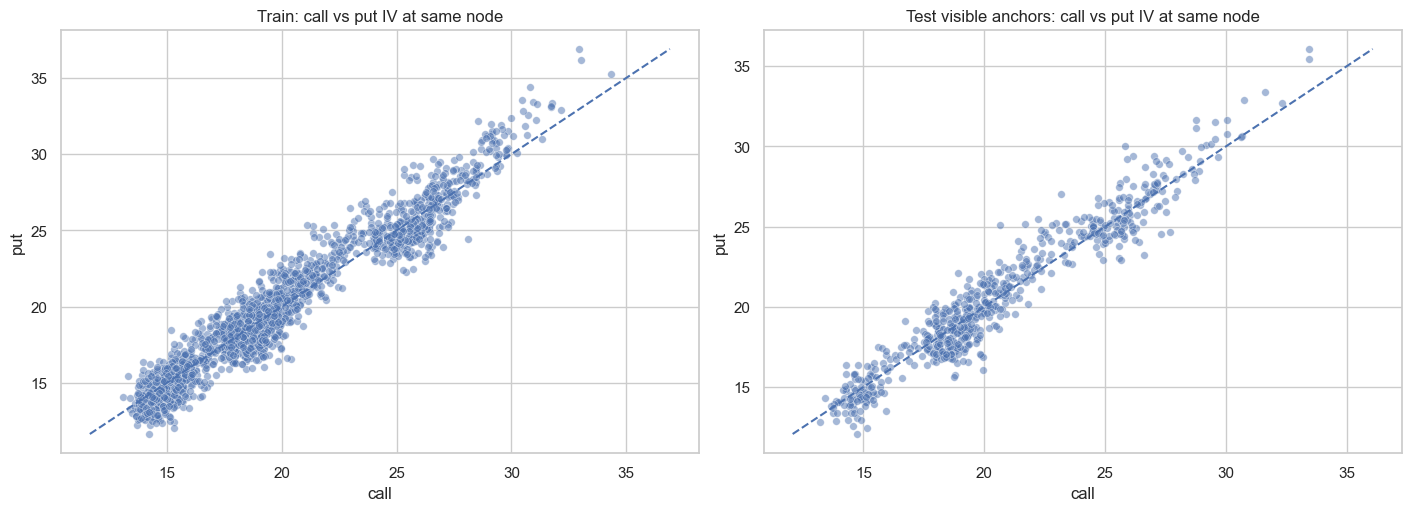

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.scatterplot(
    data=train_pairs_both,
    x="call",
    y="put",
    alpha=0.5,
    s=30,
    ax=axes[0],
)
axes[0].plot([train_pairs_both[["call", "put"]].min().min(), train_pairs_both[["call", "put"]].max().max()],
             [train_pairs_both[["call", "put"]].min().min(), train_pairs_both[["call", "put"]].max().max()],
             linestyle="--")
axes[0].set_title("Train: call vs put IV at same node")

sns.scatterplot(
    data=test_pairs_both,
    x="call",
    y="put",
    alpha=0.5,
    s=30,
    ax=axes[1],
)
axes[1].plot([test_pairs_both[["call", "put"]].min().min(), test_pairs_both[["call", "put"]].max().max()],
             [test_pairs_both[["call", "put"]].min().min(), test_pairs_both[["call", "put"]].max().max()],
             linestyle="--")
axes[1].set_title("Test visible anchors: call vs put IV at same node")

plt.show()


In [21]:
def get_nearest_moneyness(df: pd.DataFrame, target: float) -> pd.DataFrame:
    distances = (df["moneyness"] - target).abs()
    min_dist = distances.groupby(df["date"]).transform("min")
    return df.loc[min_dist.eq(distances)].copy()

train_visible = train.loc[train["iv_observed"].notna()].copy()
test_visible = test.loc[test["iv_observed"].notna()].copy()

for df in (train_visible, test_visible):
    df["log_moneyness"] = np.log(df["moneyness"])


In [22]:
def build_date_regime_proxies(df: pd.DataFrame, name: str) -> pd.DataFrame:
    atm = (
        get_nearest_moneyness(df, 1.0)
        .groupby("date")["iv_observed"]
        .mean()
        .rename("atm_iv")
    )

    left = (
        get_nearest_moneyness(df, 0.9)
        .groupby("date")["iv_observed"]
        .mean()
        .rename("iv_0p9")
    )

    right = (
        get_nearest_moneyness(df, 1.1)
        .groupby("date")["iv_observed"]
        .mean()
        .rename("iv_1p1")
    )

    short_end = (
        df.loc[df["maturity_label"] == "1M"]
        .groupby("date")["iv_observed"]
        .mean()
        .rename("iv_1m")
    )

    long_end = (
        df.loc[df["maturity_label"] == "6M"]
        .groupby("date")["iv_observed"]
        .mean()
        .rename("iv_6m")
    )

    out = pd.concat([atm, left, right, short_end, long_end], axis=1)
    out["skew_proxy"] = out["iv_0p9"] - out["iv_1p1"]
    out["term_slope_proxy"] = out["iv_1m"] - out["iv_6m"]

    print(f"{name} date-level regime proxy summary")
    display(out.describe().round(4))
    return out.sort_index()

train_regime = build_date_regime_proxies(train_visible, "Train")
test_regime = build_date_regime_proxies(test_visible, "Test visible anchors")


Train date-level regime proxy summary


,atm_iv,iv_0p9,iv_1p1,iv_1m,iv_6m,skew_proxy,term_slope_proxy
count,97.0000,97.0000,97.0000,97.0000,97.0000,97.0000,97.0000
mean,19.3117,21.2253,18.2018,21.2450,18.6768,3.0235,2.5682
std,3.9642,3.9221,4.0276,4.2039,3.7603,0.6777,0.7319
min,14.5481,16.2017,13.1945,16.0441,14.6141,1.2122,1.1665
25%,15.5088,17.6325,14.4176,17.3087,15.0448,2.6084,2.0700
50%,19.1136,21.0258,18.0504,20.9364,18.5109,3.0178,2.5389
75%,19.7926,21.8671,18.4031,22.0599,18.8450,3.5042,3.0362
max,26.6190,29.0212,25.6283,29.5128,25.6554,4.9094,4.6613


Test visible anchors date-level regime proxy summary


,atm_iv,iv_0p9,iv_1p1,iv_1m,iv_6m,skew_proxy,term_slope_proxy
count,33.0000,33.0000,33.0000,33.0000,33.0000,33.0000,33.0000
mean,20.0951,22.0296,18.9919,22.1007,19.4598,3.0377,2.6409
std,3.7841,3.9950,3.7547,4.0423,3.6031,0.7871,0.7152
min,14.8828,14.9369,13.8608,15.7587,14.8031,0.8300,0.6708
25%,19.0338,20.5488,17.7188,20.6807,18.3205,2.5402,2.2798
50%,19.2915,21.4333,18.1770,21.1252,18.6145,3.0076,2.5949
75%,19.7392,22.0334,18.8663,22.3045,19.0992,3.5003,3.1397
max,26.8924,30.2190,25.2925,29.1942,25.4284,5.2764,3.7657


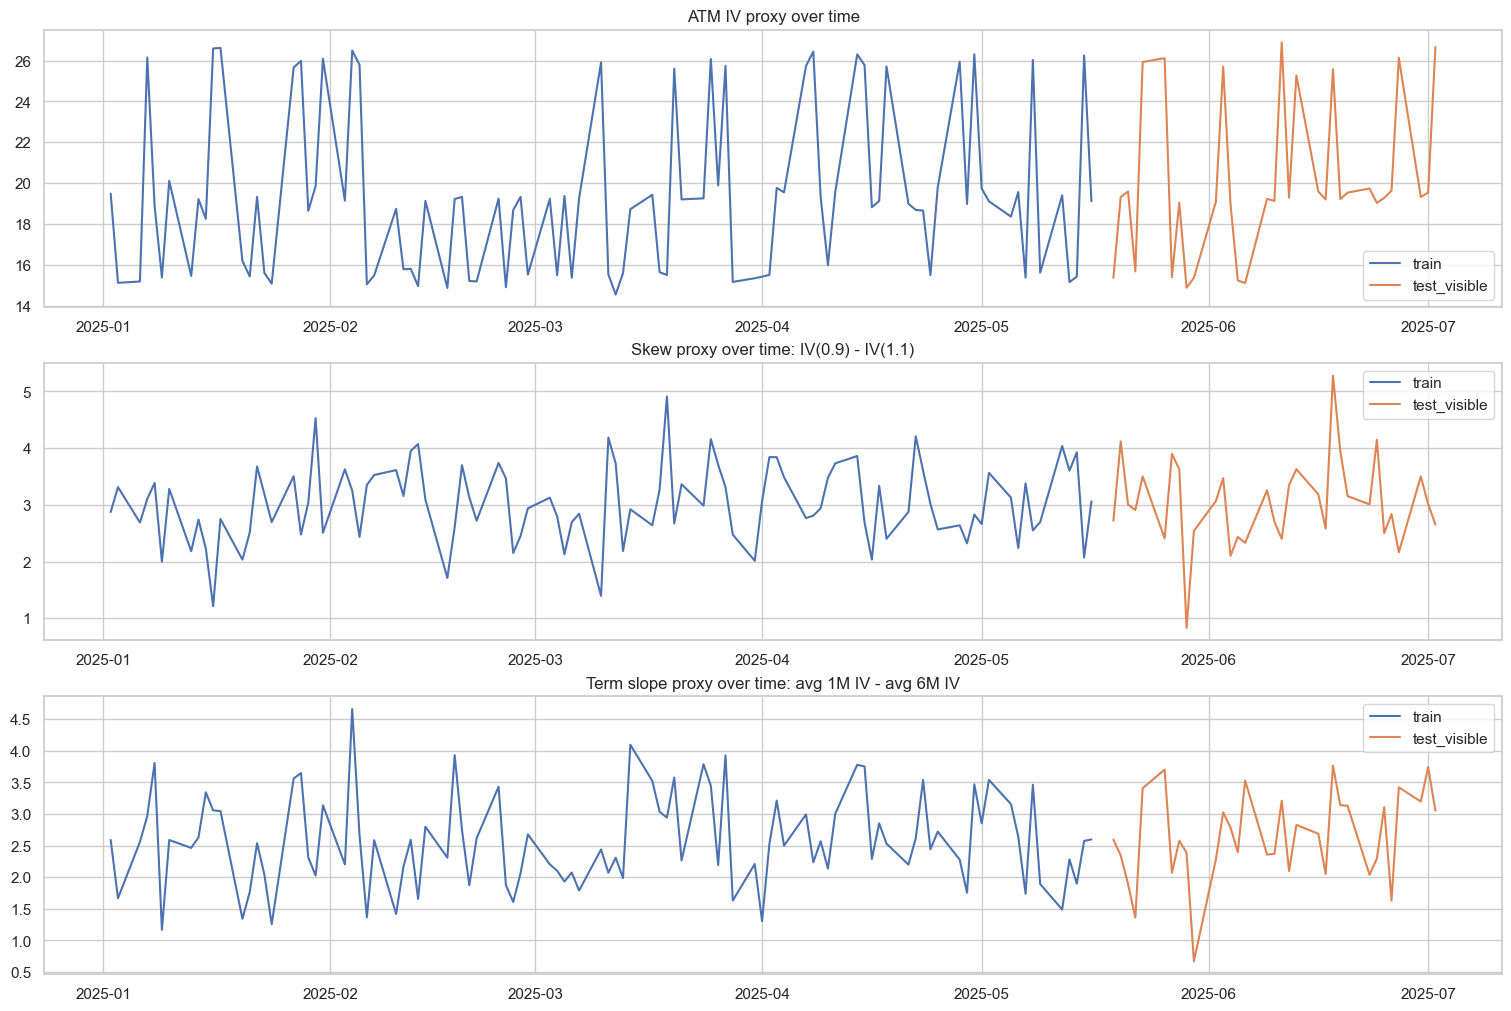

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=False, constrained_layout=True)

axes[0].plot(train_regime.index, train_regime["atm_iv"], label="train")
axes[0].plot(test_regime.index, test_regime["atm_iv"], label="test_visible")
axes[0].set_title("ATM IV proxy over time")
axes[0].legend()

axes[1].plot(train_regime.index, train_regime["skew_proxy"], label="train")
axes[1].plot(test_regime.index, test_regime["skew_proxy"], label="test_visible")
axes[1].set_title("Skew proxy over time: IV(0.9) - IV(1.1)")
axes[1].legend()

axes[2].plot(train_regime.index, train_regime["term_slope_proxy"], label="train")
axes[2].plot(test_regime.index, test_regime["term_slope_proxy"], label="test_visible")
axes[2].set_title("Term slope proxy over time: avg 1M IV - avg 6M IV")
axes[2].legend()

plt.show()


In [27]:
print("Train regime proxy correlations")
display(train_regime[["atm_iv", "skew_proxy", "term_slope_proxy"]].corr().round(4))

print("Test visible-anchor regime proxy correlations")
display(test_regime[["atm_iv", "skew_proxy", "term_slope_proxy"]].corr().round(4))


Train regime proxy correlations


,atm_iv,skew_proxy,term_slope_proxy
atm_iv,1.0000,-0.1872,0.5622
skew_proxy,-0.1872,1.0000,0.0746
term_slope_proxy,0.5622,0.0746,1.0000


Test visible-anchor regime proxy correlations


,atm_iv,skew_proxy,term_slope_proxy
atm_iv,1.0000,0.2186,0.5614
skew_proxy,0.2186,1.0000,0.1118
term_slope_proxy,0.5614,0.1118,1.0000


In [24]:
proxy_cols = ["atm_iv", "skew_proxy", "term_slope_proxy"]

def proxy_diagnostics(regime_df: pd.DataFrame, name: str):
    print(f"{name} proxy correlations")
    display(regime_df[proxy_cols].corr().round(4))

    print(f"{name} lag-1 autocorrelation")
    display(
        regime_df[proxy_cols]
        .apply(lambda s: s.autocorr(lag=1))
        .to_frame(name="lag1_autocorr")
        .round(4)
    )

proxy_diagnostics(train_regime, "Train")
proxy_diagnostics(test_regime, "Test visible anchors")


Train proxy correlations


,atm_iv,skew_proxy,term_slope_proxy
atm_iv,1.0000,-0.1872,0.5622
skew_proxy,-0.1872,1.0000,0.0746
term_slope_proxy,0.5622,0.0746,1.0000


Train lag-1 autocorrelation


,lag1_autocorr
atm_iv,0.1227
skew_proxy,0.1050
term_slope_proxy,0.0589


Test visible anchors proxy correlations


,atm_iv,skew_proxy,term_slope_proxy
atm_iv,1.0000,0.2186,0.5614
skew_proxy,0.2186,1.0000,0.1118
term_slope_proxy,0.5614,0.1118,1.0000


Test visible anchors lag-1 autocorrelation


,lag1_autocorr
atm_iv,0.0342
skew_proxy,-0.0016
term_slope_proxy,0.0446


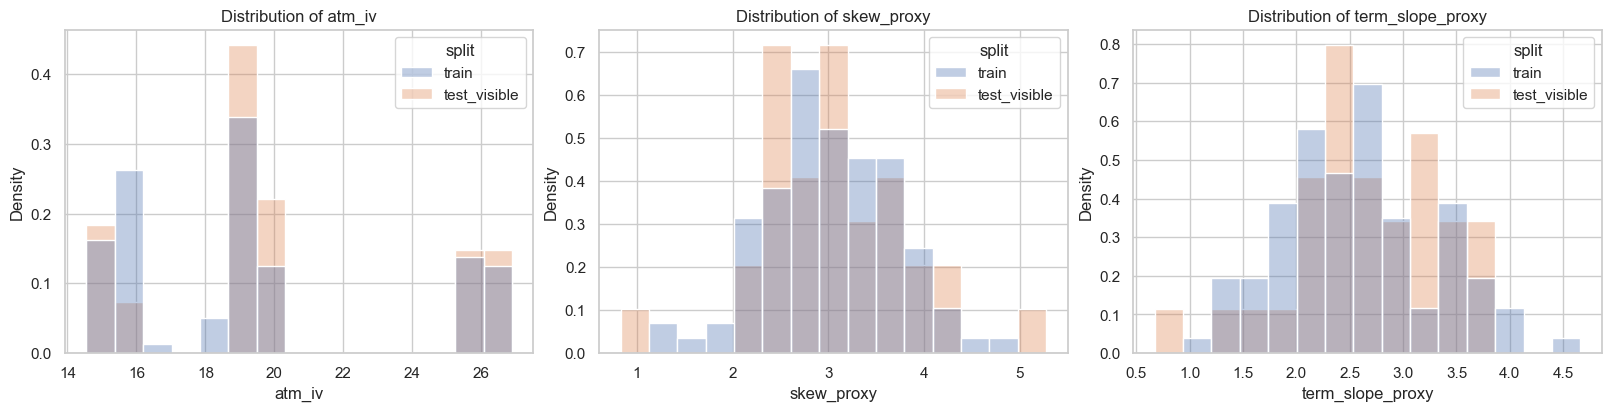

In [25]:
proxy_plot_df = pd.concat(
    [
        train_regime[proxy_cols].assign(split="train"),
        test_regime[proxy_cols].assign(split="test_visible"),
    ]
).reset_index(names="date")

fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)

for ax, col in zip(axes, proxy_cols):
    sns.histplot(
        data=proxy_plot_df,
        x=col,
        hue="split",
        stat="density",
        common_norm=False,
        bins=15,
        alpha=0.35,
        ax=ax,
    )
    ax.set_title(f"Distribution of {col}")

plt.show()


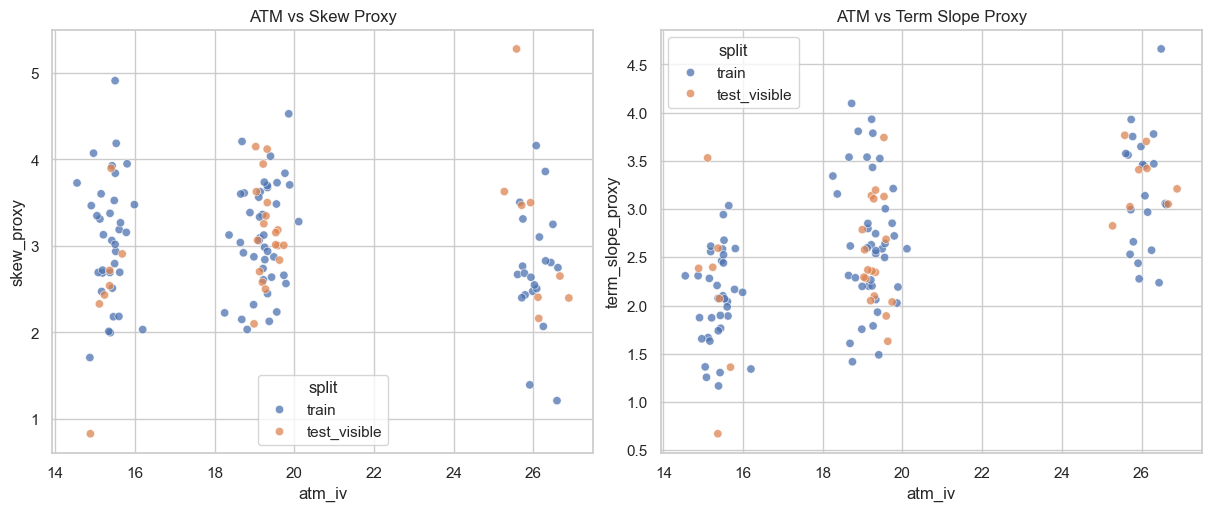

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

sns.scatterplot(
    data=proxy_plot_df,
    x="atm_iv",
    y="skew_proxy",
    hue="split",
    alpha=0.75,
    ax=axes[0],
)
axes[0].set_title("ATM vs Skew Proxy")

sns.scatterplot(
    data=proxy_plot_df,
    x="atm_iv",
    y="term_slope_proxy",
    hue="split",
    alpha=0.75,
    ax=axes[1],
)
axes[1].set_title("ATM vs Term Slope Proxy")

plt.show()


In [28]:
for df in (observed_train, observed_test):
    if "total_variance" not in df.columns:
        df["total_variance"] = (df["iv_observed"] / 100.0) ** 2 * df["tau"]

def total_variance_summary(df: pd.DataFrame, name: str):
    print(f"{name} total variance summary")
    display(
        df.groupby(["maturity_label", "option_type"])["total_variance"]
        .agg(count="size", mean="mean", std="std", min="min", median="median", max="max")
        .round(6)
    )

total_variance_summary(observed_train, "Train")
total_variance_summary(observed_test, "Test visible anchors")


Train total variance summary


count   mean    std    min  median    max
maturity_label option_type                                           
1M             call           710 0.0056 0.0025 0.0022  0.0049 0.0140
               put            725 0.0058 0.0030 0.0015  0.0050 0.0164
2M             call           846 0.0102 0.0045 0.0042  0.0088 0.0246
               put            850 0.0105 0.0050 0.0032  0.0091 0.0268
3M             call           827 0.0145 0.0062 0.0062  0.0128 0.0331
               put            847 0.0145 0.0067 0.0050  0.0125 0.0374
6M             call           826 0.0263 0.0112 0.0128  0.0236 0.0587
               put            861 0.0257 0.0111 0.0113  0.0232 0.0598

Test visible anchors total variance summary


count   mean    std    min  median    max
maturity_label option_type                                           
1M             call           252 0.0062 0.0027 0.0022  0.0052 0.0142
               put            252 0.0061 0.0028 0.0020  0.0055 0.0155
2M             call           282 0.0110 0.0044 0.0044  0.0096 0.0249
               put            292 0.0109 0.0048 0.0035  0.0095 0.0279
3M             call           301 0.0154 0.0059 0.0063  0.0135 0.0332
               put            290 0.0155 0.0065 0.0059  0.0137 0.0354
6M             call           300 0.0287 0.0110 0.0122  0.0251 0.0564
               put            292 0.0286 0.0115 0.0118  0.0246 0.0625

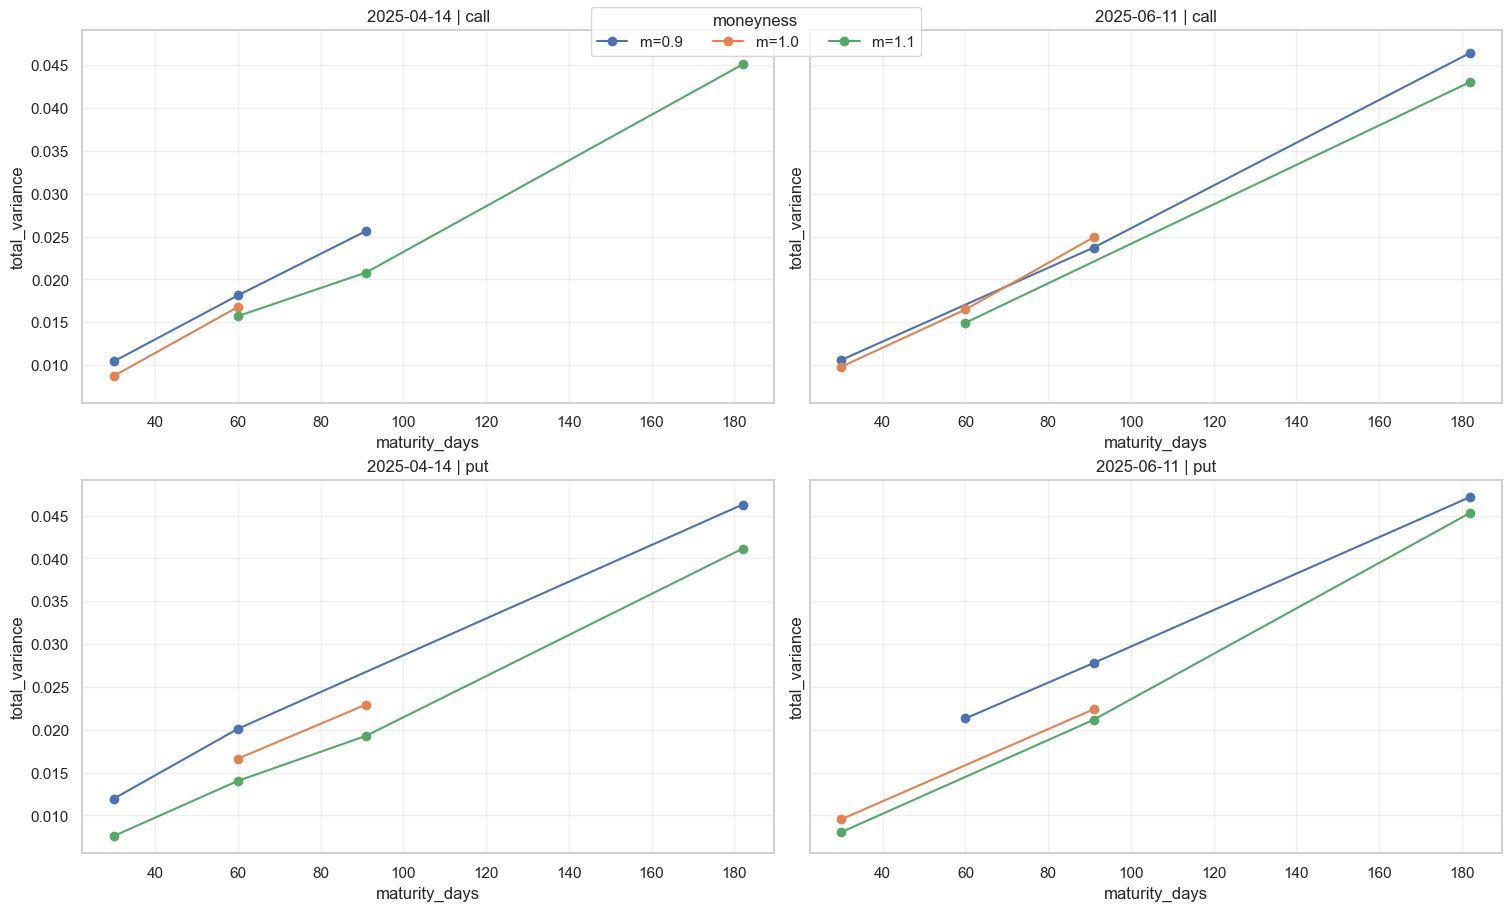

In [29]:
selected_moneyness = [0.9, 1.0, 1.1]
plot_dates = [best_train_date, best_test_date]
plot_sources = {
    best_train_date: observed_train,
    best_test_date: observed_test,
}

fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharey=True, constrained_layout=True)

for col, d in enumerate(plot_dates):
    day_df = plot_sources[d]
    day_df = day_df[day_df["date"] == d]
    for row, opt in enumerate(option_order):
        ax = axes[row, col]
        subset = day_df[day_df["option_type"] == opt]
        for m in selected_moneyness:
            s = subset[subset["moneyness"] == m].sort_values("maturity_days")
            ax.plot(s["maturity_days"], s["total_variance"], marker="o", label=f"m={m}")
        ax.set_title(f"{d.date()} | {opt}")
        ax.set_xlabel("maturity_days")
        ax.set_ylabel("total_variance")
        ax.grid(alpha=0.3)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="moneyness", loc="upper center", ncol=len(selected_moneyness))
plt.show()


In [30]:
def build_calendar_deltas(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (date, moneyness, option_type), g in df.groupby(["date", "moneyness", "option_type"]):
        g = g.sort_values("maturity_days")
        if len(g) < 2:
            continue
        vals = g[["maturity_label", "maturity_days", "total_variance"]].to_dict("records")
        for left, right in zip(vals[:-1], vals[1:]):
            rows.append(
                {
                    "date": date,
                    "moneyness": moneyness,
                    "option_type": option_type,
                    "from_maturity": left["maturity_label"],
                    "to_maturity": right["maturity_label"],
                    "from_days": left["maturity_days"],
                    "to_days": right["maturity_days"],
                    "delta_total_variance": right["total_variance"] - left["total_variance"],
                    "calendar_violation": right["total_variance"] < left["total_variance"],
                }
            )
    return pd.DataFrame(rows)

train_calendar = build_calendar_deltas(observed_train)
test_calendar = build_calendar_deltas(observed_test)

def summarize_calendar(df: pd.DataFrame, name: str):
    print(f"{name} calendar-delta summary")
    display(
        df.groupby(["from_maturity", "to_maturity"])["delta_total_variance"]
        .agg(
            count="size",
            mean="mean",
            median="median",
            violation_rate=lambda s: (s < 0).mean(),
            p10=lambda s: s.quantile(0.10),
        )
        .round(6)
    )

summarize_calendar(train_calendar, "Train")
summarize_calendar(test_calendar, "Test visible anchors")


Train calendar-delta summary


count   mean  median  violation_rate    p10
from_maturity to_maturity                                             
1M            2M             844 0.0046  0.0041          0.0000 0.0024
              3M             327 0.0086  0.0076          0.0000 0.0048
              6M             149 0.0198  0.0185          0.0000 0.0115
2M            3M             997 0.0044  0.0038          0.0000 0.0021
              6M             422 0.0159  0.0145          0.0000 0.0091
3M            6M             973 0.0119  0.0105          0.0000 0.0065

Test visible anchors calendar-delta summary


count   mean  median  violation_rate    p10
from_maturity to_maturity                                             
1M            2M             292 0.0048  0.0043          0.0000 0.0025
              3M             126 0.0097  0.0087          0.0000 0.0054
              6M              47 0.0243  0.0207          0.0000 0.0141
2M            3M             352 0.0045  0.0042          0.0000 0.0024
              6M             133 0.0174  0.0156          0.0000 0.0098
3M            6M             363 0.0132  0.0119          0.0000 0.0071

In [31]:
print("Most negative train calendar deltas")
display(
    train_calendar.sort_values("delta_total_variance")
    .head(10)
    .reset_index(drop=True)
)

print("Most negative test calendar deltas")
display(
    test_calendar.sort_values("delta_total_variance")
    .head(10)
    .reset_index(drop=True)
)


Most negative train calendar deltas


,date,moneyness,option_type,from_maturity,to_maturity,from_days,to_days,delta_total_variance,calendar_violation
0,2025-03-13,0.8750,call,2M,3M,60,91,0.0001,False
1,2025-02-25,1.1250,call,2M,3M,60,91,0.0004,False
2,2025-02-20,1.2000,put,2M,3M,60,91,0.0008,False
3,2025-04-10,1.1500,put,1M,2M,30,60,0.0009,False
4,2025-03-12,1.1000,put,2M,3M,60,91,0.0009,False
5,2025-01-09,1.1250,put,2M,3M,60,91,0.0011,False
6,2025-02-11,1.1250,call,2M,3M,60,91,0.0011,False
7,2025-03-13,1.1500,put,2M,3M,60,91,0.0012,False
8,2025-04-01,1.2000,put,2M,3M,60,91,0.0012,False
9,2025-05-14,1.0000,call,2M,3M,60,91,0.0012,False


Most negative test calendar deltas


,date,moneyness,option_type,from_maturity,to_maturity,from_days,to_days,delta_total_variance,calendar_violation
0,2025-05-19,1.0500,call,2M,3M,60,91,0.0011,False
1,2025-07-01,0.9500,call,2M,3M,60,91,0.0012,False
2,2025-05-22,1.1000,call,2M,3M,60,91,0.0012,False
3,2025-05-29,1.0750,put,1M,2M,30,60,0.0014,False
4,2025-06-06,1.2000,put,2M,3M,60,91,0.0014,False
5,2025-05-30,0.9500,call,2M,3M,60,91,0.0015,False
6,2025-05-30,1.1500,put,1M,2M,30,60,0.0015,False
7,2025-05-27,1.1000,put,2M,3M,60,91,0.0015,False
8,2025-06-20,0.8750,put,2M,3M,60,91,0.0015,False
9,2025-05-19,1.0250,put,2M,3M,60,91,0.0016,False


In [32]:
from IPython.display import Markdown, display

train_pair_ratio = len(train_pairs_both) / len(train_pairs)
test_pair_ratio = len(test_pairs_both) / len(test_pairs)

center_levels = [0.9, 0.95, 1.0, 1.05, 1.1]
wing_levels = [0.8, 0.85, 0.875, 1.125, 1.15, 1.2]

eda_metrics = pd.DataFrame(
    [
        {
            "metric": "mean_test_visible_ratio_per_date",
            "value": test_anchor_stats["visible_ratio"].mean(),
            "interpretation": "same-date anchors are broadly available on test dates",
        },
        {
            "metric": "min_test_visible_ratio_per_date",
            "value": test_anchor_stats["visible_ratio"].min(),
            "interpretation": "even sparse test dates still retain a usable anchor set",
        },
        {
            "metric": "test_call_put_paired_node_ratio",
            "value": test_pair_ratio,
            "interpretation": "opposite-option IV is often available as a soft feature",
        },
        {
            "metric": "test_mean_abs_call_put_diff",
            "value": test_pairs_both["abs_diff"].mean(),
            "interpretation": "call/put IVs are close but not identical",
        },
        {
            "metric": "test_1M_visible_ratio",
            "value": test.loc[test["maturity_label"] == "1M", "iv_observed"].notna().mean(),
            "interpretation": "short-end is the sparsest maturity bucket",
        },
        {
            "metric": "test_center_visible_ratio",
            "value": test_by_moneyness.loc[center_levels, "visible_ratio"].mean(),
            "interpretation": "center moneyness band has better coverage",
        },
        {
            "metric": "test_wing_visible_ratio",
            "value": test_by_moneyness.loc[wing_levels, "visible_ratio"].mean(),
            "interpretation": "wings are sparser but still usable",
        },
        {
            "metric": "train_calendar_violation_rate",
            "value": train_calendar["calendar_violation"].mean(),
            "interpretation": "observed train anchors are calendar-consistent in total variance",
        },
        {
            "metric": "test_calendar_violation_rate",
            "value": test_calendar["calendar_violation"].mean(),
            "interpretation": "observed test anchors are calendar-consistent in total variance",
        },
    ]
).round(4)

display(eda_metrics)


,metric,value,interpretation
0,mean_test_visible_ratio_per_date,0.5710,same-date anchors are broadly available on tes...
1,min_test_visible_ratio_per_date,0.4917,even sparse test dates still retain a usable a...
2,test_call_put_paired_node_ratio,0.3991,opposite-option IV is often available as a sof...
3,test_mean_abs_call_put_diff,0.9335,call/put IVs are close but not identical
4,test_1M_visible_ratio,0.5091,short-end is the sparsest maturity bucket
5,test_center_visible_ratio,0.6174,center moneyness band has better coverage
6,test_wing_visible_ratio,0.5101,wings are sparser but still usable
7,train_calendar_violation_rate,0.0000,observed train anchors are calendar-consistent...
8,test_calendar_violation_rate,0.0000,observed test anchors are calendar-consistent ...


In [33]:
downstream_implications = pd.DataFrame(
    [
        {
            "area": "Feature engineering",
            "decision": "Use row-local features plus anchor-derived features",
            "evidence": "stable lattice, strong same-date anchor availability, structured surface geometry",
        },
        {
            "area": "Feature engineering",
            "decision": "Include opposite-option IV as a soft feature, not a hard equality constraint",
            "evidence": "call-put paired ratio is meaningful, median gap is sub-1 vol point, but differences are real",
        },
        {
            "area": "Feature engineering",
            "decision": "Include date-level proxies: ATM, skew, term slope",
            "evidence": "all vary materially by date and train/test distributions overlap",
        },
        {
            "area": "Feature engineering",
            "decision": "Use total-variance representations for maturity-aware features/models",
            "evidence": "calendar consistency is very clean in total variance",
        },
        {
            "area": "Validation design",
            "decision": "Split by date with time ordering",
            "evidence": "train dates precede test dates; row-wise random CV would leak structure",
        },
        {
            "area": "Validation design",
            "decision": "Mask within validation dates while preserving visible anchors",
            "evidence": "real test setup is partial same-date surface completion, not full-date forecasting",
        },
        {
            "area": "Validation design",
            "decision": "Match masking structure by maturity x moneyness x option_type as much as practical",
            "evidence": "missingness is clearly structured, especially by maturity and moneyness",
        },
        {
            "area": "Modeling priority",
            "decision": "Prioritize structured surface models, tabular ML, and hybrids first",
            "evidence": "surface geometry, anchor coverage, and date-level signals are already strong",
        },
    ]
)

display(downstream_implications)


,area,decision,evidence
0,Feature engineering,Use row-local features plus anchor-derived fea...,"stable lattice, strong same-date anchor availa..."
1,Feature engineering,"Include opposite-option IV as a soft feature, ...","call-put paired ratio is meaningful, median ga..."
2,Feature engineering,"Include date-level proxies: ATM, skew, term slope",all vary materially by date and train/test dis...
3,Feature engineering,Use total-variance representations for maturit...,calendar consistency is very clean in total va...
4,Validation design,Split by date with time ordering,train dates precede test dates; row-wise rando...
5,Validation design,Mask within validation dates while preserving ...,real test setup is partial same-date surface c...
6,Validation design,Match masking structure by maturity x moneynes...,"missingness is clearly structured, especially ..."
7,Modeling priority,"Prioritize structured surface models, tabular ...","surface geometry, anchor coverage, and date-le..."


In [34]:
model_priority = pd.DataFrame(
    [
        {
            "model_family": "Structured surface interpolation / smoothing",
            "priority": "High",
            "why": "strong smile/skew + term structure + good anchor coverage",
        },
        {
            "model_family": "Tabular ML with anchor/date features",
            "priority": "High",
            "why": "EDA supports rich engineered features beyond raw row fields",
        },
        {
            "model_family": "Hybrid surface + residual ML",
            "priority": "High",
            "why": "surface structure is strong but not perfectly rigid",
        },
        {
            "model_family": "Matrix / tensor completion",
            "priority": "Medium-Low",
            "why": "plausible, but simpler structured methods are justified first",
        },
        {
            "model_family": "Graph / GNN-style models",
            "priority": "Low for now",
            "why": "conceptually natural, but current evidence does not require that complexity yet",
        },
    ]
)

display(model_priority)


,model_family,priority,why
0,Structured surface interpolation / smoothing,High,strong smile/skew + term structure + good anch...
1,Tabular ML with anchor/date features,High,EDA supports rich engineered features beyond r...
2,Hybrid surface + residual ML,High,surface structure is strong but not perfectly ...
3,Matrix / tensor completion,Medium-Low,"plausible, but simpler structured methods are ..."
4,Graph / GNN-style models,Low for now,"conceptually natural, but current evidence doe..."


In [35]:
display(
    Markdown(
        """
### EDA Exit Summary

**What EDA has established**
- The problem is a stable date-wise IV lattice with partial same-date observation.
- Missingness is structured, especially by maturity and moneyness.
- Same-date anchors are strong enough to support completion-style methods.
- Call and put IVs are closely related but not identical.
- Date-level state summaries are useful as continuous features.
- Total variance behaves cleanly across maturity.

**What this means for next phases**
- Phase 2 should build a date-based, anchor-preserving validation framework.
- Phase 3-6 should prioritize structured surface methods, anchor-aware features, and hybrids.
- Advanced graph/tensor branches are optional later, not immediate priorities.
"""
    )
)



### EDA Exit Summary

**What EDA has established**
- The problem is a stable date-wise IV lattice with partial same-date observation.
- Missingness is structured, especially by maturity and moneyness.
- Same-date anchors are strong enough to support completion-style methods.
- Call and put IVs are closely related but not identical.
- Date-level state summaries are useful as continuous features.
- Total variance behaves cleanly across maturity.

**What this means for next phases**
- Phase 2 should build a date-based, anchor-preserving validation framework.
- Phase 3-6 should prioritize structured surface methods, anchor-aware features, and hybrids.
- Advanced graph/tensor branches are optional later, not immediate priorities.


In [36]:
# --- Phase 1.5 / Cell 1: submission + integrity checks ---

KEY_COLS = ["date", "moneyness", "maturity_label", "option_type"]

print("=== SAMPLE SUBMISSION CONSISTENCY ===")
test_missing_ids = set(test.loc[test["iv_observed"].isna(), "row_id"])
sample_ids = set(sample_submission["row_id"])

print("Missing rows in test:", len(test_missing_ids))
print("Rows in sample_submission:", len(sample_ids))
print("Exact row_id match:", test_missing_ids == sample_ids)
print("In sample but not in missing test:", len(sample_ids - test_missing_ids))
print("In missing test but not in sample:", len(test_missing_ids - sample_ids))

print("\n=== DUPLICATE KEY CHECKS ===")
train_dup = train.duplicated(KEY_COLS).sum()
test_dup = test.duplicated(KEY_COLS).sum()
print("Train duplicate keys:", train_dup)
print("Test duplicate keys:", test_dup)

print("\n=== MATURITY CONSISTENCY CHECKS ===")
maturity_check = (
    pd.concat(
        [
            train[["maturity_label", "maturity_days", "tau"]],
            test[["maturity_label", "maturity_days", "tau"]],
        ],
        ignore_index=True,
    )
    .drop_duplicates()
    .sort_values(["maturity_days", "maturity_label"])
)
display(maturity_check)

print("\n=== MONEyness SANITY CHECK ===")
for name, df in [("train", train), ("test", test)]:
    rel_err = np.abs(df["moneyness"] - (df["strike"] / df["spot"]))
    print(f"{name}: max |moneyness - strike/spot| = {rel_err.max():.12f}")

=== SAMPLE SUBMISSION CONSISTENCY ===
Missing rows in test: 1699
Rows in sample_submission: 1699
Exact row_id match: True
In sample but not in missing test: 0
In missing test but not in sample: 0

=== DUPLICATE KEY CHECKS ===
Train duplicate keys: 0
Test duplicate keys: 0

=== MATURITY CONSISTENCY CHECKS ===


,maturity_label,maturity_days,tau
0,1M,30,0.1191
30,2M,60,0.2381
60,3M,91,0.3611
90,6M,182,0.7222



=== MONEyness SANITY CHECK ===
train: max |moneyness - strike/spot| = 0.001265833116
test: max |moneyness - strike/spot| = 0.001249705318


In [37]:
# --- Phase 1.5 / Cell 2: build same-date visibility support for missing test rows ---

test_obs = test[test["iv_observed"].notna()].copy()
test_miss = test[test["iv_observed"].isna()].copy()

obs_key_set = set(
    zip(
        test_obs["date"],
        test_obs["moneyness"],
        test_obs["maturity_label"],
        test_obs["option_type"],
    )
)

moneyness_levels = sorted(test["moneyness"].unique())
maturity_levels = (
    test[["maturity_label", "maturity_days"]]
    .drop_duplicates()
    .sort_values("maturity_days")["maturity_label"]
    .tolist()
)

m_idx = {m: i for i, m in enumerate(moneyness_levels)}
t_idx = {t: i for i, t in enumerate(maturity_levels)}

def opposite_option(opt):
    return "put" if opt == "call" else "call"

def count_same_maturity_neighbors(date, m, tau_label, opt):
    i = m_idx[m]
    candidates = []
    if i - 1 >= 0:
        candidates.append((date, moneyness_levels[i - 1], tau_label, opt))
    if i + 1 < len(moneyness_levels):
        candidates.append((date, moneyness_levels[i + 1], tau_label, opt))
    return sum(c in obs_key_set for c in candidates)

def count_same_moneyness_neighbors(date, m, tau_label, opt):
    j = t_idx[tau_label]
    candidates = []
    if j - 1 >= 0:
        candidates.append((date, m, maturity_levels[j - 1], opt))
    if j + 1 < len(maturity_levels):
        candidates.append((date, m, maturity_levels[j + 1], opt))
    return sum(c in obs_key_set for c in candidates)

def opposite_visible(date, m, tau_label, opt):
    return (date, m, tau_label, opposite_option(opt)) in obs_key_set

test_miss = test_miss.copy()

test_miss["opp_option_visible"] = [
    opposite_visible(d, m, t, o)
    for d, m, t, o in zip(
        test_miss["date"],
        test_miss["moneyness"],
        test_miss["maturity_label"],
        test_miss["option_type"],
    )
]

test_miss["same_maturity_adj_visible_count"] = [
    count_same_maturity_neighbors(d, m, t, o)
    for d, m, t, o in zip(
        test_miss["date"],
        test_miss["moneyness"],
        test_miss["maturity_label"],
        test_miss["option_type"],
    )
]

test_miss["same_moneyness_adj_visible_count"] = [
    count_same_moneyness_neighbors(d, m, t, o)
    for d, m, t, o in zip(
        test_miss["date"],
        test_miss["moneyness"],
        test_miss["maturity_label"],
        test_miss["option_type"],
    )
]

test_miss["has_local_same_date_support"] = (
    test_miss["opp_option_visible"]
    | (test_miss["same_maturity_adj_visible_count"] > 0)
    | (test_miss["same_moneyness_adj_visible_count"] > 0)
)

display(test_miss.head())

,row_id,date,spot,strike,moneyness,option_type,maturity_label,maturity_days,tau,iv_observed,opp_option_visible,same_maturity_adj_visible_count,same_moneyness_adj_visible_count,has_local_same_date_support
3,11643,2025-05-19,"20,254.5700",17200,0.8500,put,1M,30,0.1191,NaN,True,1,0,True
5,11645,2025-05-19,"20,254.5700",17700,0.8750,put,1M,30,0.1191,NaN,True,1,1,True
8,11648,2025-05-19,"20,254.5700",18750,0.9250,call,1M,30,0.1191,NaN,True,1,1,True
10,11650,2025-05-19,"20,254.5700",19250,0.9500,call,1M,30,0.1191,NaN,False,1,0,True
11,11651,2025-05-19,"20,254.5700",19250,0.9500,put,1M,30,0.1191,NaN,False,1,1,True


In [38]:
# --- Phase 1.5 / Cell 3: summarize target-node support ---

print("=== TARGET-NODE SUPPORT SUMMARY (missing test rows) ===")
n = len(test_miss)

summary = pd.Series(
    {
        "missing_test_rows": n,
        "opp_option_visible_rate": test_miss["opp_option_visible"].mean(),
        "same_maturity_adj_visible_rate": (test_miss["same_maturity_adj_visible_count"] > 0).mean(),
        "same_maturity_both_adj_visible_rate": (test_miss["same_maturity_adj_visible_count"] == 2).mean(),
        "same_moneyness_adj_visible_rate": (test_miss["same_moneyness_adj_visible_count"] > 0).mean(),
        "same_moneyness_both_adj_visible_rate": (test_miss["same_moneyness_adj_visible_count"] == 2).mean(),
        "any_local_same_date_support_rate": test_miss["has_local_same_date_support"].mean(),
    }
)
display(summary.to_frame("value"))

print("\n=== SUPPORT BY MATURITY x OPTION_TYPE ===")
support_by_group = (
    test_miss.groupby(["maturity_label", "option_type"])
    .agg(
        n=("row_id", "size"),
        opp_option_visible_rate=("opp_option_visible", "mean"),
        same_maturity_adj_visible_rate=("same_maturity_adj_visible_count", lambda s: (s > 0).mean()),
        same_moneyness_adj_visible_rate=("same_moneyness_adj_visible_count", lambda s: (s > 0).mean()),
        any_local_support_rate=("has_local_same_date_support", "mean"),
    )
    .reset_index()
)
display(support_by_group)

print("\n=== SUPPORT BY MONEyness ===")
support_by_m = (
    test_miss.groupby("moneyness")
    .agg(
        n=("row_id", "size"),
        opp_option_visible_rate=("opp_option_visible", "mean"),
        same_maturity_adj_visible_rate=("same_maturity_adj_visible_count", lambda s: (s > 0).mean()),
        same_moneyness_adj_visible_rate=("same_moneyness_adj_visible_count", lambda s: (s > 0).mean()),
        any_local_support_rate=("has_local_same_date_support", "mean"),
    )
    .reset_index()
    .sort_values("moneyness")
)
display(support_by_m)

=== TARGET-NODE SUPPORT SUMMARY (missing test rows) ===


,value
missing_test_rows,"1,699.0000"
opp_option_visible_rate,0.5715
same_maturity_adj_visible_rate,0.7793
same_maturity_both_adj_visible_rate,0.2743
same_moneyness_adj_visible_rate,0.6786
same_moneyness_both_adj_visible_rate,0.1524
any_local_same_date_support_rate,0.9647



=== SUPPORT BY MATURITY x OPTION_TYPE ===


,maturity_label,option_type,n,opp_option_visible_rate,same_maturity_adj_visible_rate,same_moneyness_adj_visible_rate,any_local_support_rate
0,1M,call,243,0.5144,0.7284,0.5720,0.9300
1,1M,put,243,0.5144,0.7449,0.5885,0.9342
2,2M,call,213,0.5728,0.7324,0.7793,0.9812
3,2M,put,203,0.5517,0.8227,0.7833,1.0000
4,3M,call,194,0.6237,0.7732,0.7887,0.9691
5,3M,put,205,0.6439,0.8146,0.8049,0.9854
6,6M,call,195,0.5795,0.8154,0.6000,0.9590
7,6M,put,203,0.5961,0.8227,0.5468,0.9704



=== SUPPORT BY MONEyness ===


,moneyness,n,opp_option_visible_rate,same_maturity_adj_visible_rate,same_moneyness_adj_visible_rate,any_local_support_rate
0,0.8000,125,0.5680,0.5760,0.6080,0.8880
1,0.8500,123,0.5285,0.7642,0.7236,0.9593
2,0.8750,124,0.5323,0.8548,0.7258,1.0000
3,0.9000,96,0.6042,0.8021,0.7604,0.9792
4,0.9250,109,0.5596,0.9541,0.7890,0.9817
5,0.9500,96,0.6875,0.8958,0.7917,0.9896
6,0.9750,104,0.5962,0.8269,0.6827,0.9808
7,1.0000,93,0.6344,0.7742,0.7634,0.9570
8,1.0250,104,0.6154,0.8269,0.6827,0.9712
9,1.0500,105,0.5238,0.8381,0.6476,0.9905


In [39]:
# --- Phase 1.5 / Cell 4: isolate hard missing test nodes ---

hard_cases = test_miss[
    (~test_miss["opp_option_visible"])
    & (test_miss["same_maturity_adj_visible_count"] == 0)
    & (test_miss["same_moneyness_adj_visible_count"] == 0)
].copy()

print("=== HARD TARGET CASES ===")
print("Count:", len(hard_cases))
print("Rate:", len(hard_cases) / len(test_miss))

print("\nBy maturity x option_type:")
display(
    hard_cases.groupby(["maturity_label", "option_type"])
    .size()
    .rename("count")
    .reset_index()
)

print("\nSample hard cases:")
display(
    hard_cases[
        ["row_id", "date", "moneyness", "maturity_label", "option_type", "spot", "strike"]
    ].head(20)
)

=== HARD TARGET CASES ===
Count: 60
Rate: 0.03531489111241907

By maturity x option_type:


,maturity_label,option_type,count
0,1M,call,17
1,1M,put,16
2,2M,call,4
3,3M,call,6
4,3M,put,3
5,6M,call,8
6,6M,put,6



Sample hard cases:


,row_id,date,moneyness,maturity_label,option_type,spot,strike
23,11663,2025-05-19,1.1000,1M,put,"20,254.5700",22300
60,11700,2025-05-19,0.8000,3M,call,"20,254.5700",16200
62,11702,2025-05-19,0.8500,3M,call,"20,254.5700",17200
131,11771,2025-05-20,0.9500,1M,put,"20,263.9100",19250
178,11818,2025-05-20,1.2000,2M,call,"20,263.9100",24300
358,11998,2025-05-21,1.2000,6M,call,"20,215.0300",24250
373,12013,2025-05-22,0.9750,1M,put,"19,882.5400",19400
374,12014,2025-05-22,1.0000,1M,call,"19,882.5400",19900
478,12118,2025-05-22,1.2000,6M,call,"19,882.5400",23850
625,12265,2025-05-26,1.1250,1M,put,"19,717.0100",22200


In [40]:
# --- Phase 1.5 / Cell 5: hard-case rate by maturity x moneyness ---

if "is_hard_case" not in test_miss.columns:
    test_miss["is_hard_case"] = (
        (~test_miss["opp_option_visible"])
        & (test_miss["same_maturity_adj_visible_count"] == 0)
        & (test_miss["same_moneyness_adj_visible_count"] == 0)
    )

maturity_order = (
    test[["maturity_label", "maturity_days"]]
    .drop_duplicates()
    .sort_values("maturity_days")["maturity_label"]
    .tolist()
)

moneyness_order = sorted(test["moneyness"].unique().tolist())

hard_case_table = (
    test_miss.groupby(["maturity_label", "moneyness"])
    .agg(
        n=("row_id", "size"),
        hard_case_count=("is_hard_case", "sum"),
        hard_case_rate=("is_hard_case", "mean"),
    )
    .reset_index()
)

display(hard_case_table.sort_values(["maturity_label", "moneyness"]))


,maturity_label,moneyness,n,hard_case_count,hard_case_rate
0,1M,0.8000,28,4,0.1429
1,1M,0.8500,39,1,0.0256
2,1M,0.8750,37,0,0.0000
3,1M,0.9000,25,0,0.0000
4,1M,0.9250,30,1,0.0333
5,1M,0.9500,28,1,0.0357
6,1M,0.9750,34,2,0.0588
7,1M,1.0000,31,4,0.1290
8,1M,1.0250,33,3,0.0909
9,1M,1.0500,28,0,0.0000


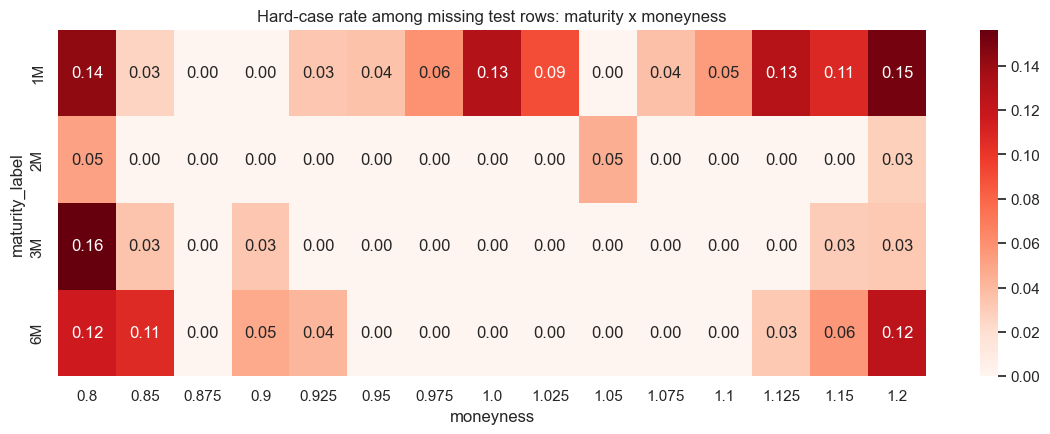

In [41]:
hard_case_heatmap = (
    hard_case_table.pivot(
        index="maturity_label",
        columns="moneyness",
        values="hard_case_rate",
    )
    .reindex(index=maturity_order, columns=moneyness_order)
)

plt.figure(figsize=(14, 4.5))
sns.heatmap(
    hard_case_heatmap,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    vmin=0.0,
    vmax=max(0.15, float(hard_case_heatmap.max().max())),
)
plt.title("Hard-case rate among missing test rows: maturity x moneyness")
plt.xlabel("moneyness")
plt.ylabel("maturity_label")
plt.show()


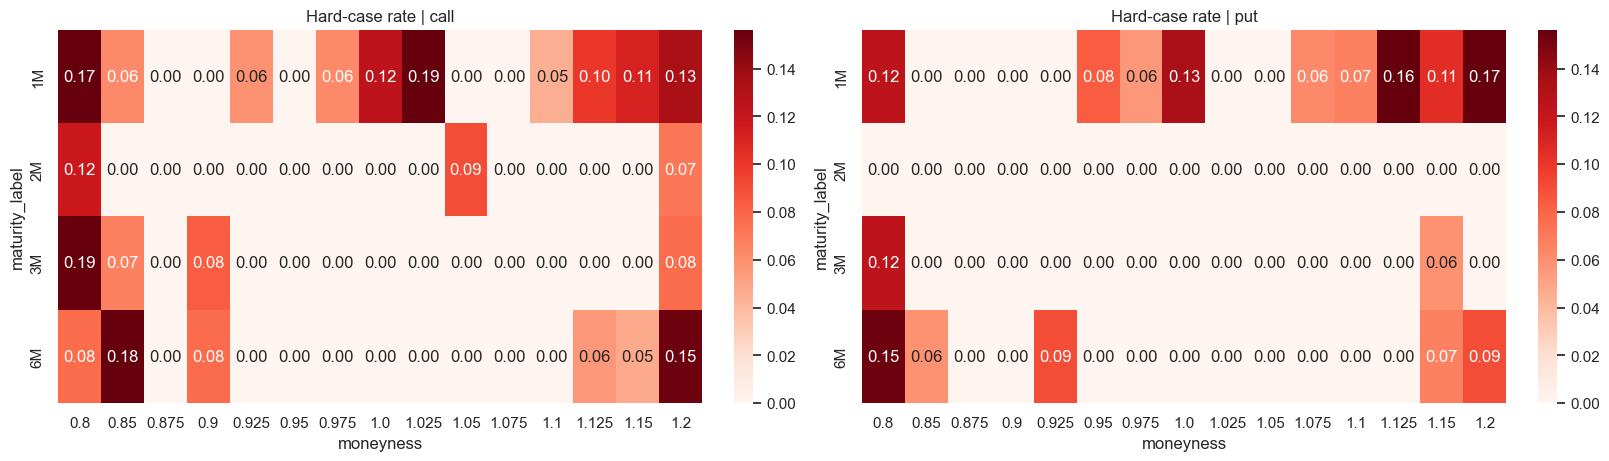

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5), constrained_layout=True)

for ax, opt in zip(axes, ["call", "put"]):
    opt_heatmap = (
        test_miss.loc[test_miss["option_type"] == opt]
        .groupby(["maturity_label", "moneyness"])["is_hard_case"]
        .mean()
        .reset_index()
        .pivot(index="maturity_label", columns="moneyness", values="is_hard_case")
        .reindex(index=maturity_order, columns=moneyness_order)
    )
    sns.heatmap(
        opt_heatmap,
        annot=True,
        fmt=".2f",
        cmap="Reds",
        vmin=0.0,
        vmax=max(0.15, float(hard_case_heatmap.max().max())),
        ax=ax,
    )
    ax.set_title(f"Hard-case rate | {opt}")
    ax.set_xlabel("moneyness")
    ax.set_ylabel("maturity_label")

plt.show()


## Hard-case diagnostic: locally unsupported missing test nodes

To better understand how difficult the test completion problem really is, we defined a **strict local hard-case rule** for missing test nodes.

A missing test node is marked as a **hard case** if all three of the following same-date support channels are absent:

1. The **opposite option** is not visible at the exact same `(date, moneyness, maturity)` node.
2. There are **no immediate adjacent moneyness neighbors** visible at the same `(date, maturity, option_type)`.
3. There are **no immediate adjacent maturity neighbors** visible at the same `(date, moneyness, option_type)`.

This is intentionally a **strict local-support definition**. A hard case is therefore **locally isolated**, but not necessarily impossible to predict. It may still be predictable from broader same-date structure, more distant anchors, historical behavior, or date-level features.

### What we found

- Only a **small minority** of missing test rows are hard cases, roughly **3.5%** of the missing test targets.
- Most missing targets still have at least one useful same-date local support channel.
- Hard cases are **not uniformly distributed** across the surface.
- They are concentrated mainly in:
  - **1M** maturity
  - the **wings / edge moneyness regions**
  - some smaller pockets in **3M** and **6M**
- The central region of the surface is usually much better locally supported.

### Why this matters

This result strengthens the case for:

- **same-date structured interpolation / smoothing**
- **anchor-aware feature engineering**
- **hybrid models** that combine local surface structure with learned corrections

It also suggests that later validation and model comparison should report performance not only overall, but also separately for:

- **hard cases**
- **non-hard cases**
- **short-end rows**, especially `1M`
- **wing regions**

The hard-case diagnostic therefore gives us a practical way to separate "ordinary completion" from the more difficult sparse-support subset of the competition.


## Phase 1 EDA summary and downstream implications

The EDA establishes that this problem is best understood as **time-ordered, partial implied-volatility surface completion**, not generic row-wise regression.

### 1. Dataset structure

- Each date forms a stable IV lattice over:
  - **15 moneyness levels**
  - **4 maturities**
  - **2 option types**
- Every date contains exactly **120 rows**.
- `train.csv` contains earlier dates and `test.csv` contains later dates.
- The train and test datasets share the same lattice structure.

This confirms that the natural unit of modeling is the **date-level surface**, not an isolated row.

### 2. Missingness and same-date anchors

- The test set is only **partially missing**, not fully hidden.
- Same-date visible anchors are consistently available on test dates.
- Missingness is **structured**, especially by:
  - **maturity**
  - **moneyness**
- `1M` is the sparsest maturity bucket.
- The center of the moneyness range is generally better observed than the wings.
- Call and put visibility rates are broadly similar.

This means validation must mimic **future-date partial-surface completion with anchors preserved**, rather than full-date forecasting or random row masking.

### 3. Surface geometry

Observed IV values show clear, finance-consistent structure:

- a pronounced **equity-index-style downside skew**
- meaningful **term structure**
- smooth enough same-date geometry to support interpolation and surface fitting
- related but not identical call and put surfaces

This strongly supports using:

- local same-date interpolation / smoothing
- surface-aware engineered features
- structured models before more exotic approaches

### 4. Call-put relationship

At the same `(date, moneyness, maturity)` node:

- call and put IVs are usually **close**
- but they are **not identical**
- the short end (`1M`) shows the largest call-put disagreement

So opposite-option information should be treated as a **strong soft feature**, not as a hard equality constraint.

### 5. Date-level state / regime proxies

Date-level summaries such as:

- approximate **ATM IV**
- **skew proxy**
- **term slope proxy**

vary meaningfully across dates and have similar distributions in train and visible test anchors.

These are useful as **continuous date-level features**. However, their lag-1 persistence is not strong enough to justify a hard regime-state model at this stage.

### 6. Total variance and maturity consistency

When the surface is viewed in **total variance** rather than raw IV:

- maturity behavior is very clean
- calendar consistency is strong
- observed anchors show essentially no calendar violations

This suggests that maturity-aware structured methods should reason in **total-variance space** where appropriate.

### 7. Main downstream implications

The EDA supports the following project direction:

#### Validation design
- split by **date**, not by row
- preserve **time ordering**
- mask only part of validation dates so that **same-date anchors remain visible**
- try to mimic missingness structure by **maturity x moneyness x option_type** as much as practical

#### Feature engineering
- include **row-local features**
- include **anchor-derived local support features**
- include **opposite-option features**
- include **date-level proxies** such as ATM, skew, and term slope
- consider **total-variance-based maturity features**

#### Model priority
Highest priority:
- **structured surface interpolation / smoothing**
- **tabular ML with anchor-aware features**
- **hybrid surface + residual models**

Lower immediate priority:
- matrix / tensor completion
- graph / GNN-style methods

### Final EDA conclusion

The dataset has enough structure, enough same-date anchor support, and enough financial regularity to justify a strong notebook-first path:

1. build a faithful validation framework
2. establish anchor-aware baselines
3. test structured surface models
4. test tabular ML with engineered features
5. combine the best ideas in hybrids

Phase 1 EDA therefore gives a clear and defensible foundation for moving into **Phase 2: validation design**.
